# Pipeline de Inspeção Visual e Classificação de Peças de Fundição Metálica Defeituosas

## SUMÁRIO

1. INTRODUÇÃO E CONTEXTUALIZAÇÃO
2. OBJETIVOS DO PROJETO
3. PREPARAÇÃO DO AMBIENTE
4. CONFIGURAÇÃO DE CAMINHOS E HIPERPARÂMETROS
5. COLETA DE AMOSTRAS PARA ANÁLISE EXPLORATÓRIA
6. VISUALIZAÇÃO DAS IMAGENS ORIGINAIS
7. PIPELINE OPENCV — GRAYSCALE E SUAVIZAÇÃO
8. PIPELINE OPENCV — LIMIARIZAÇÃO, BORDAS E MORFOLOGIA
9. INTERPRETAÇÃO DA ANÁLISE EXPLORATÓRIA CLÁSSICA
10. INGESTÃO DE DADOS EM LOTE COM KERAS
11. DATA AUGMENTATION DINÂMICO
12. OTIMIZAÇÃO DO PIPELINE DE ENTRADA
13. ARQUITETURA DA CNN
14. COMPILAÇÃO E TREINAMENTO
15. AUDITORIA GRÁFICA DO TREINAMENTO
16. AVALIAÇÃO FINAL E INTERPRETAÇÃO DOS RESULTADOS
17. CONSIDERAÇÕES FINAIS

## 1. INTRODUÇÃO E CONTEXTUALIZAÇÃO

A ascensão da **Indústria 4.0** redefiniu os padrões operacionais das linhas de produção modernas, introduzindo tecnologias inteligentes voltadas à máxima otimização de processos e à garantia rigorosa de controle de qualidade. No cenário metalúrgico atual, a transição de processos manuais para sistemas automatizados de auditoria tornou-se um diferencial competitivo crucial. Inspeções visuais de peças realizadas por operadores humanos são inerentemente demoradas, exaustivas e sujeitas a inconsistências causadas pela fadiga. 

Para solucionar essa vulnerabilidade, o mercado exige soluções de engenharia capazes de integrar de forma sinérgica duas grandes vertentes da computação: a **Visão Computacional Clássica** e a **Inteligência Artificial (IA)**. 

Antes de submeter grandes volumes de dados a algoritmos de aprendizado profundo, a aplicação de processamento digital de imagens clássico (utilizando bibliotecas como a **OpenCV**) desempenha um papel fundamental. Esse tratamento inicial atua na análise exploratória das amostras, sendo responsável pela filtragem de ruídos industriais, realce de contrastes, detecção de bordas estruturais e isolamento morfológico das características físicas das falhas. Compreender a natureza geométrica do defeito precede e viabiliza o sucesso do aprendizado computacional.

Uma vez compreendidas e evidenciadas essas características, as **Redes Neurais Convolucionais (CNNs)** entram em cena para automatizar a classificação em larga escala através do framework **TensorFlow/Keras**. Alimentadas por pipelines eficientes de ingestão de dados e técnicas avançadas de *Data Augmentation* — essenciais para blindar o modelo contra variações reais do ambiente fabril, como oscilações de iluminação e posicionamento de peças na esteira — as CNNs adquirem a robustez necessária para atuar de forma autônoma e confiável no chão de fábrica.

Este projeto utiliza como base o conjunto de dados público *Casting Product Image Data for Quality Inspection*, composto por imagens reais de peças de fundição metálica segmentadas entre estruturas íntegras ("OK") e estruturas com anomalias geométricas ou trincas ("Defeituosas") e implementa um pipeline completo para inspeção de qualidade em peças fundidas, cobrindo:

1. **Análise exploratória** com OpenCV para evidenciar defeitos visuais;
2. **Treinamento de uma CNN** com TensorFlow/Keras para classificação automática entre peças **OK** e **Defeituosas**;
3. **Auditoria do treinamento** com gráficos de *Loss* e *Acurácia*.




## 2. OBJETIVOS DO PROJETO

O objetivo principal deste projeto é desenvolver e documentar um *pipeline* completo em Python que unifique o processamento digital de imagens e o aprendizado profundo para criar um sistema automatizado e robusto de controle de qualidade industrial. 

Para alcançar a meta principal, o projeto desdobra-se nos seguintes objetivos específicos:

* **Desenvolver um Pipeline de Processamento Clássico (OpenCV):** Implementar filtros de conversão de espaço de cor (*Grayscale*) e suavização de ruídos (*Gaussian/Median Blur*) em imagens amostrais do *dataset*.
* **Isolar Visualmente os Defeitos de Fundição:** Aplicar técnicas de limiarização (*Thresholding*), algoritmos seletores de gradiente e bordas (*Canny/Sobel*) e operadores morfológicos (*Erosão e Dilatação*) para destacar de forma inequívoca trincas, porosidades e ranhuras na superfície metálica das peças.
* **Estruturar a Ingestão e Imunização de Dados (Keras):** Configurar o carregamento otimizado de lotes via `image_dataset_from_directory`, realizando a divisão estocástica controlada entre conjuntos de treino e validação, além de aplicar uma camada sequencial de *Data Augmentation* dinâmico (rotação, zoom e brilho) para simular as condições dinâmicas de uma esteira industrial.
* **Projetar e Treinar uma CNN Personalizada:** Construir uma arquitetura de rede neural convolucional sequencial estruturada com blocos intercalados de extração de características (`Conv2D` e `MaxPooling2D`), seguida por uma transição matricial eficiente (`Flatten`) e camadas densas de decisão com função de ativação sigmoide para classificação binária.
* **Validar e Auditar o Desempenho do Modelo:** Monitorar o comportamento do aprendizado ao longo das épocas por meio da geração e análise de curvas analíticas de perda (*Loss/Val_Loss*) e acurácia (*Accuracy/Val_Accuracy*), garantindo a entrega de um modelo generalista e livre de *overfitting*.

## 3. PREPARAÇÃO DO AMBIENTE

Nesta etapa será feito o carregamento das bibliotecas necessárias para:

- manipulação de arquivos e amostragem;
- processamento de imagens com OpenCV;
- visualização com Matplotlib/Seaborn;
- modelagem e treinamento com TensorFlow/Keras.


In [1]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
print('TensorFlow:', tf.__version__)


TensorFlow: 2.21.0


## 4. CONFIGURAÇÃO DE CAMINHOS E HIPERPARÂMETROS

Nesta sessão serão definidas as variáveis centrais para facilitar manutenção e reuso do notebook:

- caminho do dataset;
- resolução das imagens;
- tamanho do lote;
- número de épocas;
- semente para reprodutibilidade.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_DIR = Path('./data/casting_512x512')

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 100
VAL_SPLIT = 0.2

if not DATASET_DIR.exists():
    print(f'Atenção: diretório {DATASET_DIR.resolve()} não encontrado.')
    print('Atualize a variável DATASET_DIR para o caminho correto do dataset.')
else:
    print('Dataset localizado em:', DATASET_DIR.resolve())


Dataset localizado em: C:\Users\Camila\Desktop\SCTEC\Módulo 2\Mini Projeto\sctec-projeto-III-rede-neural-convolucional\data\casting_512x512


## 5. COLETA DE AMOSTRAS PARA ANÁLISE EXPLORATÓRIA

Antes de treinar o modelo, será selecionado uma pequena amostra de imagens para inspeção visual.

Essa etapa permite verificar:

- variações de iluminação e textura;
- aparência típica de peças sem defeito e com defeito;
- nível de ruído presente nas imagens industriais.


In [3]:
def listar_imagens(base_dir):
    extensoes = {'.png', '.jpg', '.jpeg', '.bmp'}
    imagens = [p for p in base_dir.rglob('*') if p.suffix.lower() in extensoes]
    return imagens

def coletar_amostras_por_classe(base_dir, n_por_classe=3):
    amostras = []
    classes = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    for classe in classes:
        imgs = listar_imagens(classe)
        if imgs:
            amostras.extend(random.sample(imgs, k=min(n_por_classe, len(imgs))))
    return amostras

if DATASET_DIR.exists():
    sample_paths = coletar_amostras_por_classe(DATASET_DIR, n_por_classe=3)
    print(f'Amostras coletadas: {len(sample_paths)}')
else:
    sample_paths = []


Amostras coletadas: 6


## 6. VISUALIZAÇÃO DAS IMAGENS ORIGINAIS

Com as amostras selecionadas, as imagens originais serão exibidas para criar uma linha de base visual.

Essa referência será comparada com as etapas clássicas (blur, bordas e morfologia), para avaliar se os defeitos se tornam mais evidentes.


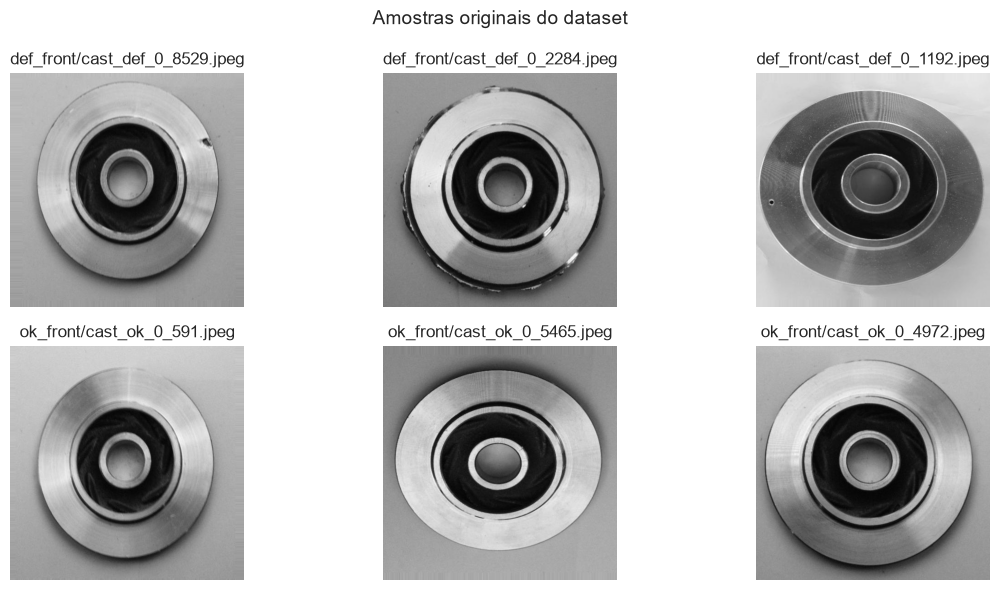

In [4]:
def mostrar_grade_imagens(paths, titulo='Amostras originais', cmap=None, cols=3):
    if not paths:
        print('Nenhuma imagem para exibir.')
        return

    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    for i, p in enumerate(paths, start=1):
        img_bgr = cv2.imread(str(p))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(img_rgb, cmap=cmap)
        plt.title(f'{p.parent.name}/{p.name[:30]}')
        plt.axis('off')
    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

mostrar_grade_imagens(sample_paths, titulo='Amostras originais do dataset')


## 7. PIPELINE OPENCV — GRAYSCALE E SUAVIZAÇÃO

Inicialmente, serão aplicadas duas operações fundamentais de pré-processamento clássico:

1. **Escala de cinza** para reduzir complexidade da imagem (de 3 canais para 1);
2. **Gaussian Blur** para reduzir ruído de alta frequência sem destruir completamente bordas relevantes.

Essas transformações preparam a imagem para limiarização e detecção de bordas mais estável.


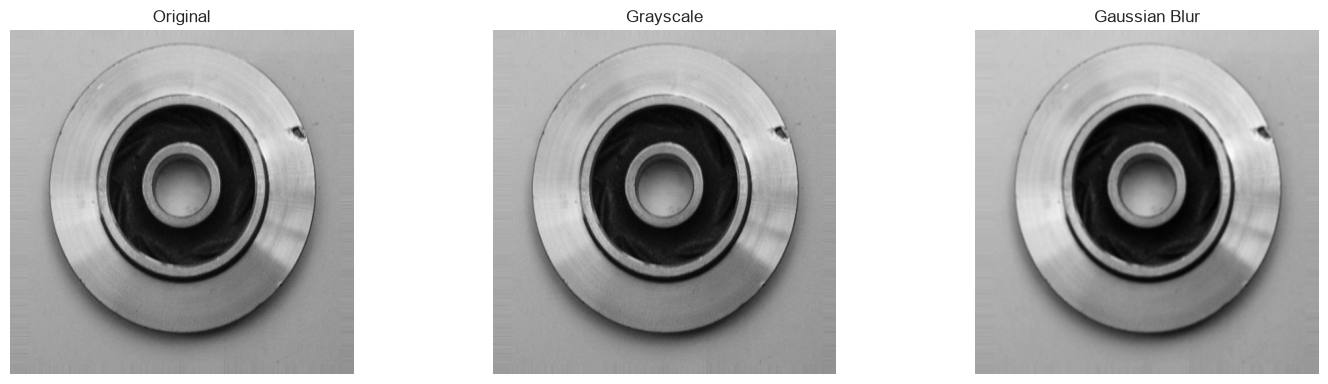

In [5]:
def processar_grayscale_blur(img_bgr, ksize=(5, 5), sigma=0):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, ksize, sigma)
    return gray, blur

if sample_paths:
    exemplo = cv2.imread(str(sample_paths[0]))
    gray, blur = processar_grayscale_blur(exemplo)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(exemplo, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Grayscale')
    axes[2].imshow(blur, cmap='gray')
    axes[2].set_title('Gaussian Blur')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 8. PIPELINE OPENCV — LIMIARIZAÇÃO, BORDAS E MORFOLOGIA

Nesta etapa, o objetivo é destacar potenciais trincas/ranhuras usando:

- **Thresholding (Otsu)**: separa regiões claras/escuras automaticamente;
- **Canny**: detecta contornos significativos;
- **Dilatação e erosão**: reforçam traços úteis e reduzem pequenas falhas na segmentação.

A sequência ajuda a isolar visualmente regiões suspeitas de defeito.


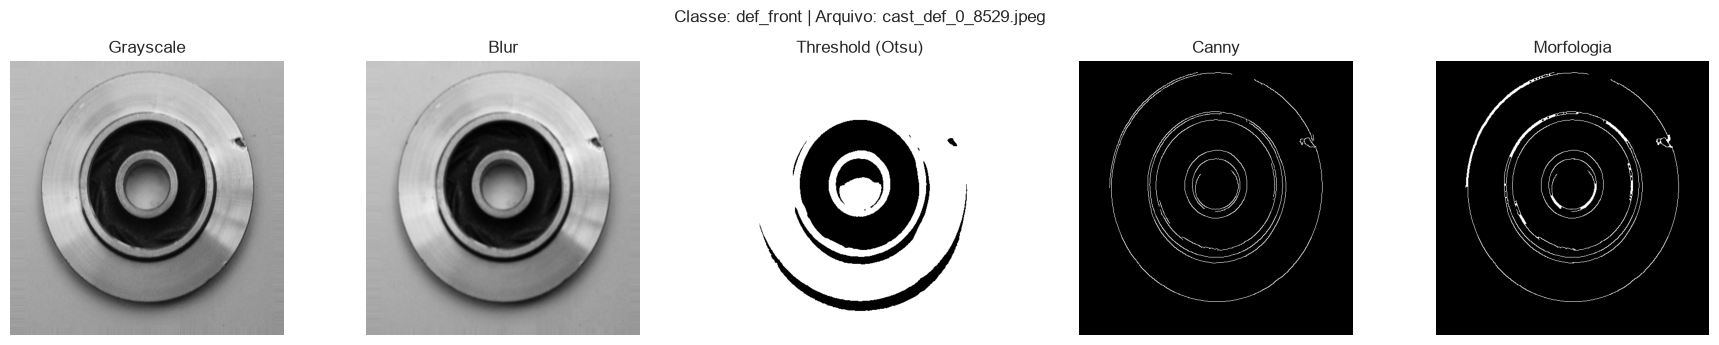

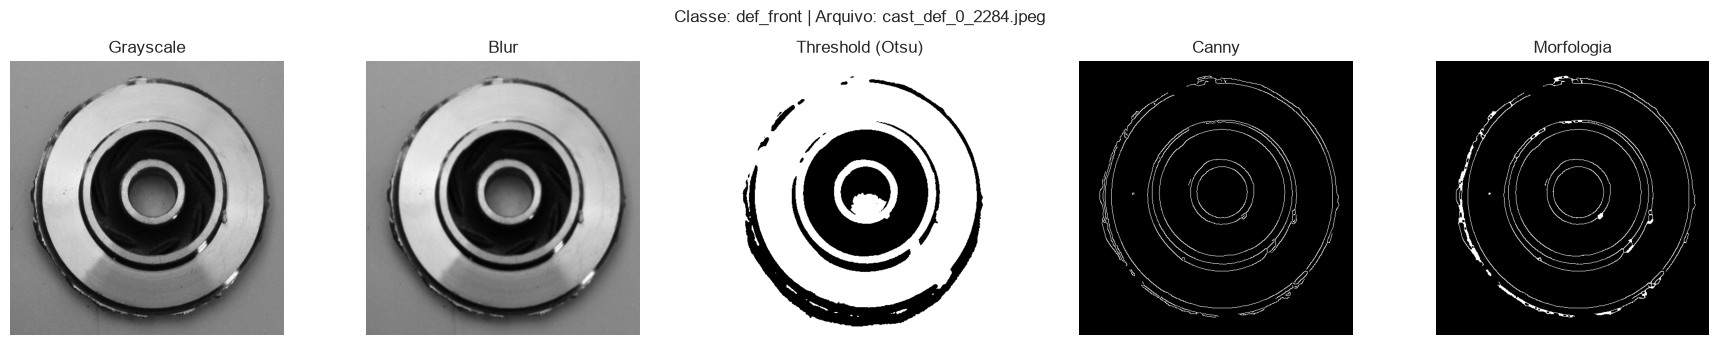

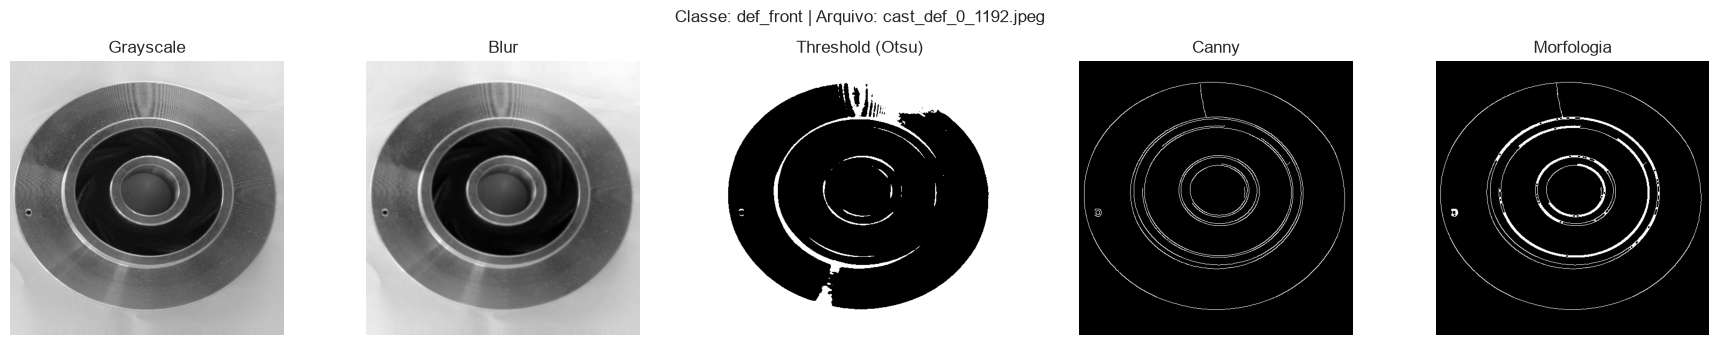

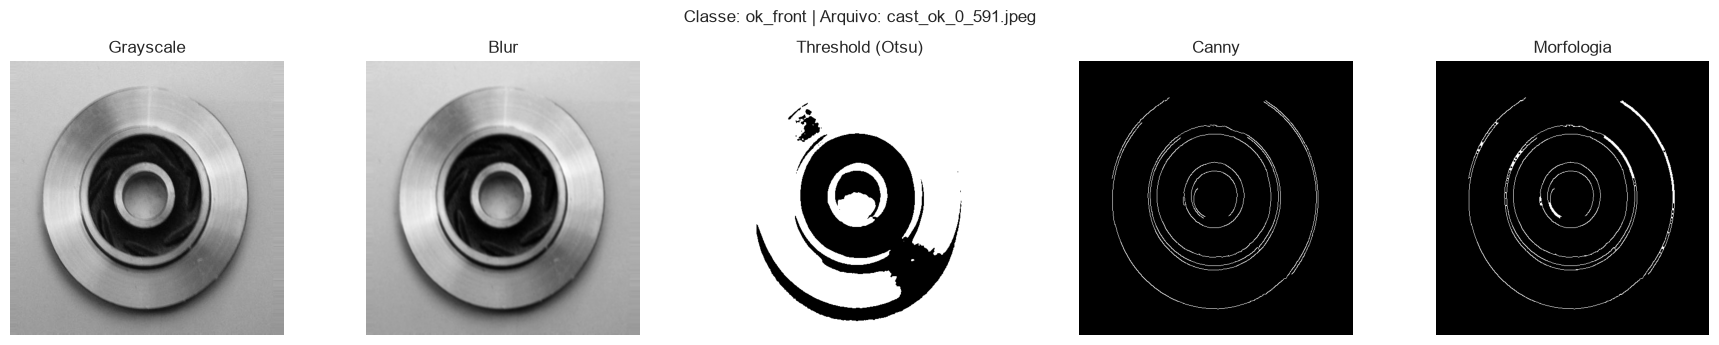

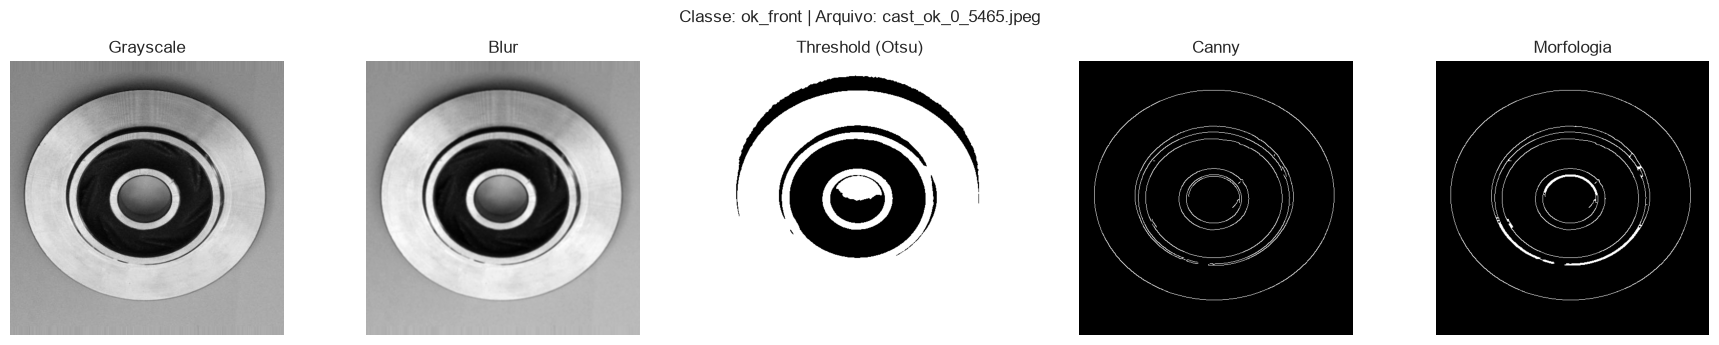

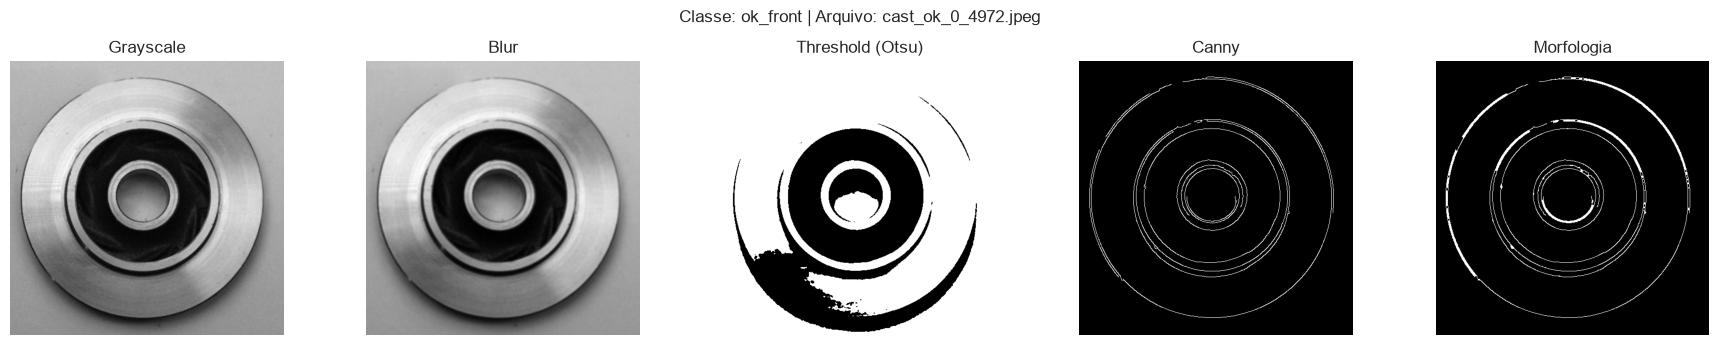

In [6]:
def extrair_caracteristicas_open_cv(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges = cv2.Canny(blur, 50, 150)

    kernel = np.ones((3, 3), np.uint8)
    dilatada = cv2.dilate(edges, kernel, iterations=1)
    morfologia = cv2.erode(dilatada, kernel, iterations=1)

    return {
        'gray': gray,
        'blur': blur,
        'threshold': thresh,
        'canny': edges,
        'morfologia': morfologia,
    }

if sample_paths:
    for path in sample_paths[:]:
        img = cv2.imread(str(path))
        etapas = extrair_caracteristicas_open_cv(img)

        fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
        fig.suptitle(f'Classe: {path.parent.name} | Arquivo: {path.name}', fontsize=12)

        axes[0].imshow(etapas['gray'], cmap='gray')
        axes[0].set_title('Grayscale')
        axes[1].imshow(etapas['blur'], cmap='gray')
        axes[1].set_title('Blur')
        axes[2].imshow(etapas['threshold'], cmap='gray')
        axes[2].set_title('Threshold (Otsu)')
        axes[3].imshow(etapas['canny'], cmap='gray')
        axes[3].set_title('Canny')
        axes[4].imshow(etapas['morfologia'], cmap='gray')
        axes[4].set_title('Morfologia')

        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()


## 9. INTERPRETAÇÃO DA ANÁLISE EXPLORATÓRIA CLÁSSICA

A análise visual dos resultados revela que o processamento teve um bom desempenho na identificação das anomalias, destacando-se de forma excelente em defeitos macroestruturais e geométricos, mas enfrentando desafios em trincas filiformes devido a ruídos de iluminação e reflexos nas peças metálicas.

- *Grayscale e Blur*: Cumpriram perfeitamente a função de suavizar texturas micro-abrasivas inerentes ao metal injetado sem apagar os limites das bordas estruturais;
- *Threshold (Otsu)*: Sofreu forte interferência das condições de iluminação e brilho reflexivo do metal. Em imagens como a `cast_ok_0_591.jpeg`, o reflexo da luz gerou uma grande mancha preta contínua na base, o que poderia causar um falso positivo (confundindo reflexo com defeito estrutural);
- *Canny e Morfologia*: Funcionaram como excelentes extratores de alta frequência. A morfologia ajudou a limpar pequenas bordas irrelevantes detectadas pelo Canny. O resultado final ("Morfologia") entrega imagens binárias limpas nas quais as descontinuidades de formato tornam-se nítidas.


Essa análise exploratória nos mostra que, embora o processamento clássico seja capaz de isolar e destacar geometrias anômalas (como visto nas rebarbas e furos), ele falha em ser 100% confiável devido a variações de iluminação e reflexos que geram ruído nas bordas. Isso justifica o uso da CNN, pois será capaz de ignorar as variações de brilho que enganam o algoritmo de Otsu e focar nos padrões espaciais profundos e robustos das trincas reais.


## 10. INGESTÃO DE DADOS EM LOTE COM KERAS

Concluída a etapa da análise exploratória, o dataset completo será carregado com `image_dataset_from_directory`, incluindo divisão automática de **treino** e **validação**.

Isso garante uma rotina padronizada, eficiente e reproduzível para treinamento supervisionado binário.


In [7]:
if DATASET_DIR.exists():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=VAL_SPLIT,
        subset='training',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=VAL_SPLIT,
        subset='validation',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )

    class_names = train_ds.class_names
    print('Classes identificadas:', class_names)
else:
    train_ds, val_ds, class_names = None, None, []


Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.
Classes identificadas: ['def_front', 'ok_front']


## 11. DATA AUGMENTATION DINÂMICO

Para simular variações reais de uma esteira industrial, será implementado o aumento de dados a partir de das técnicas:

- **RandomRotation** (rotação);
- **RandomZoom** (aproximação/afastamento);
- **ajuste de brilho** via `tf.image.random_brightness`.

Essa estratégia reduz sobreajuste e melhora robustez do classificador.


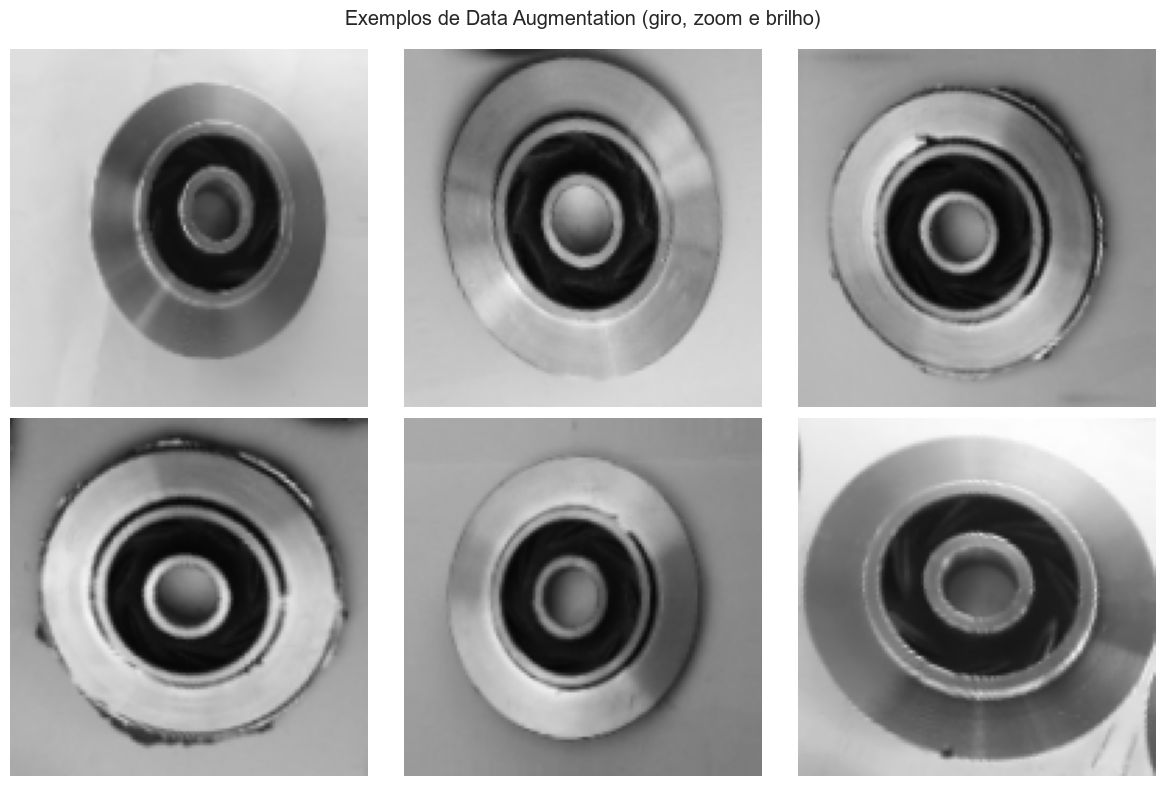

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.6, seed=SEED),
    layers.RandomZoom(0.05, seed=SEED),
    layers.Lambda(lambda x: tf.clip_by_value(tf.image.random_brightness(x, 0.10), 0.0, 255.0)),
], name='data_augmentation')

if train_ds is not None:
    imagens_batch, _ = next(iter(train_ds.take(1)))
    plt.figure(figsize=(12, 8))
    for i in range(6):
        aug = data_augmentation(tf.expand_dims(imagens_batch[i], 0), training=True)
        plt.subplot(2, 3, i + 1)
        plt.imshow(tf.cast(aug[0], tf.uint8).numpy())
        plt.axis('off')
    plt.suptitle('Exemplos de Data Augmentation (giro, zoom e brilho)')
    plt.tight_layout()
    plt.show()


## 12. OTIMIZAÇÃO DO PIPELINE DE ENTRADA

`cache()` e `prefetch()` serão aplicados para acelerar leitura e preparo dos lotes durante o treinamento, reduzindo gargalos de I/O.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

if train_ds is not None:
    train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 13. ARQUITETURA DA CNN

A arquitetura da rede faz uso de um modelo Sequential com blocos intercalados **Conv2D + MaxPooling2D**, com:

- extração progressiva de padrões visuais;
- redução espacial controlada;
- camada `Flatten` para transição para decisão densa;
- saída sigmoide para classificação binária.


In [10]:
model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='cnn_casting_inspection')

model.summary()


Model: "cnn_casting_inspection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 14. COMPILAÇÃO E TREINAMENTO

O modelo será compilado com:

- **otimizador Adam** (boa convergência em problemas de visão);
- **Binary Crossentropy** (problema binário);
- métrica de **acurácia** para monitoramento.

Também será usado `EarlyStopping` para reduzir risco de overfitting.


In [11]:
history = None

if train_ds is not None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )


Epoch 1/100


c:\Users\Camila\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 476ms/step - accuracy: 0.5885 - loss: 0.7360 - val_accuracy: 0.5731 - val_loss: 0.6700
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 447ms/step - accuracy: 0.6481 - loss: 0.6295 - val_accuracy: 0.7038 - val_loss: 0.5989
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 453ms/step - accuracy: 0.6990 - loss: 0.5993 - val_accuracy: 0.7077 - val_loss: 0.5783
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 454ms/step - accuracy: 0.7038 - loss: 0.5752 - val_accuracy: 0.7038 - val_loss: 0.5969
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 451ms/step - accuracy: 0.7038 - loss: 0.5806 - val_accuracy: 0.7385 - val_loss: 0.5493
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 458ms/step - accuracy: 0.7096 - loss: 0.5559 - val_accuracy: 0.7000 - val_loss: 0.5692
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 450ms/step - accuracy: 0.7067 - loss: 0.5562 - val_accuracy: 0.7115 - val_loss: 0.5544
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 447ms/step - accuracy: 0.7337 - loss: 0.5456 - val_accuracy

## 15. AUDITORIA GRÁFICA DO TREINAMENTO

Para acompanhar a evolução do treinamento, serão geradas as curvas de **Loss** e **Acurácia** para treino e validação. Essas curvas permitem analisar:

- qualidade da convergência;
- presença de underfitting/overfitting;
- estabilidade do processo de aprendizado.


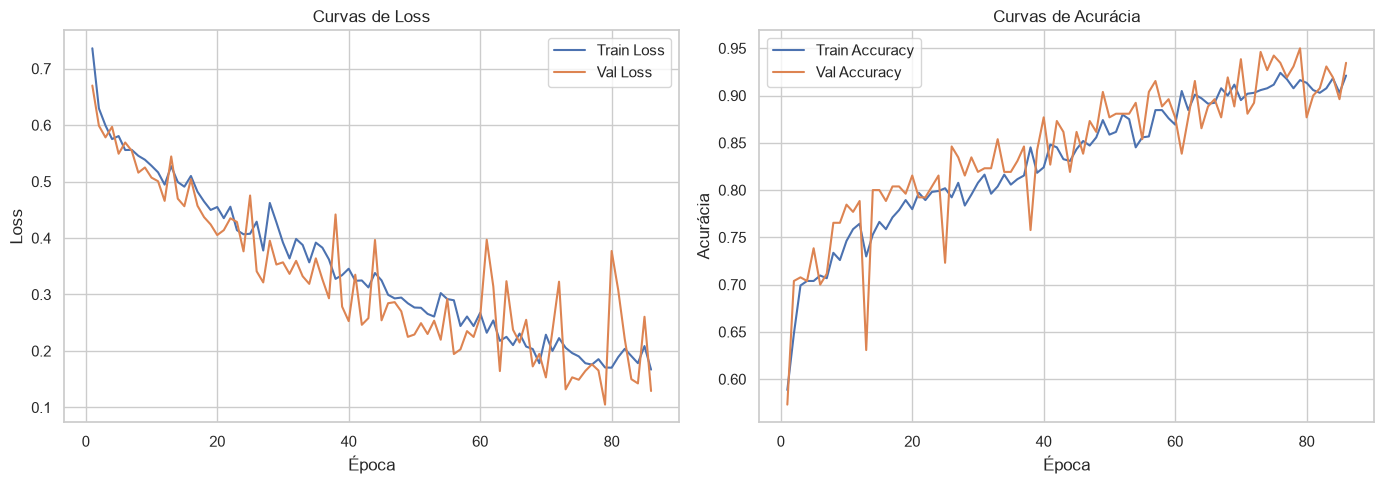

In [12]:
if history is not None:
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, hist['loss'], label='Train Loss')
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss')
    axes[0].set_title('Curvas de Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs_range, hist['accuracy'], label='Train Accuracy')
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Val Accuracy')
    axes[1].set_title('Curvas de Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


A análise visual dos gráficos indica que o treinamento da CNN foi altamente bem-sucedido, estável e atingiu excelente capacidade de generalização, chegando à época 86 com métricas robustas.

### Análise da Curva de Perda (*Loss*)

- *Tendência de Convergência*: Train Loss e Val Loss decresceram de forma contínua e sincronizadas, convergindo para valores próximos a 0.15 - 0.20. Isso comprova que a rede aprendeu as características estruturais das peças em vez de apenas memorizá-las;
- *Ausência de Overfitting*: O sinal mais positivo do gráfico é que Val Loss acompanha Train Loss até o final do treinamento. Não há o comportamento de "boca de jacaré" (onde a perda de treino cai e a de validação começa a subir), o que garante que o modelo está pronto para executar em produção;
- *Ruídos na Validação*: É possível observar oscilações pontuais (picos) na curva de validação. Esse comportamento é normal e esperado devido à aplicação das técnicas severas de Data Augmentation e ao Dropout em um conjunto de dados pequeno.


### Análise da Curva de Acurácia (*Accuracy*)

- *Evolução do Aprendizado*: A acurácia parte de uma base próxima a 60% na primeira época e escala de forma consistente até atingir um patamar consolidado entre 92% e 95% a partir da época 70;
- *Comportamento Híbrido*: Em vários momentos do treino, a acurácia de validação fica ligeiramente acima ou entrelaçada com a acurácia de treino. Isso é reflexo direto do uso do Dropout(0.6) na camada densa, que dificulta o aprendizado no treino e, assim, o modelo tende a performar com métricas ligeiramente mais limpas e otimizadas no momento da validação;
- *Estabilização*: Observa-se que entre as épocas 70 e 86, as curvas começam a andar de lado, o que indica que o modelo esgotou sua capacidade de ganho com os parâmetros atuais. 

## 16. AVALIAÇÃO FINAL E INTERPRETAÇÃO DOS RESULTADOS

Além da análise das curvas de perda e acurária, também será gerada a matriz de confusão e o relatório de classificação.

Isso permite verificar se o modelo está equilibrado entre:

- identificar peças boas (classe OK);
- detectar corretamente peças defeituosas (classe crítica para qualidade).


Val Loss: 0.1051
Val Accuracy: 0.9500


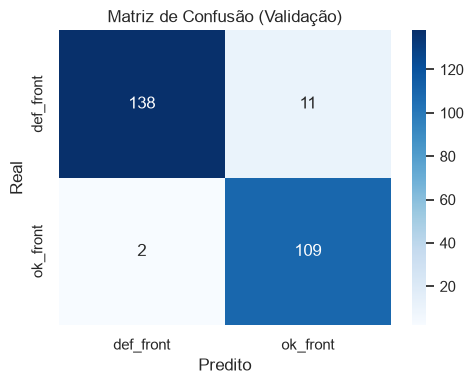

Relatório de classificação:
              precision    recall  f1-score   support

   def_front     0.9857    0.9262    0.9550       149
    ok_front     0.9083    0.9820    0.9437       111

    accuracy                         0.9500       260
   macro avg     0.9470    0.9541    0.9494       260
weighted avg     0.9527    0.9500    0.9502       260



In [13]:
if val_ds is not None and history is not None:
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f'Val Loss: {val_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.4f}')

    y_true = []
    y_pred = []

    for x_batch, y_batch in val_ds:
        probs = model.predict(x_batch, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_true.extend(y_batch.numpy().ravel().astype(int))
        y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão (Validação)')
    plt.tight_layout()
    plt.show()

    print('Relatório de classificação:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


O resultado do treinamento mostra que o modelo alcançou uma acurácia global de **95.00%** (com uma perda de validação de apenas 0.1051).

### Análise da Matriz de Confusão

A matriz avalia o cruzamento entre o que a peça realmente é (Real) e o que o modelo afirmou que ela era (Predito), totalizando 260 peças testadas.

- *Verdadeiros Positivos*: O modelo identificou corretamente 138 peças defeituosas;   
- *Verdadeiros Negativos*: O modelo classificou corretamente 109 peças saudáveis;   
- *Falsos Negativos (Risco Industrial Crítico)*: Em apenas 11 casos, uma peça que realmente tinha defeito passou pelo modelo e foi classificada como íntegra;   
- *Falsos Positivos (Desperdício Econômico)*: Em apenas 2 casos, uma peça totalmente saudável foi classificada incorretamente como defeituosa.


### Interpretação do Relatório de Classificação


Ao analisar o relatório de classificação, observa-se que o modelo apresentou uma **precisão de 98.57%** na identificação de falhas, isso significa que quando uma peça metálica é apontada como defeituosa, existe quase 100% de certeza de que ela realmente possui uma anomalia estrutural. Por outro lado, o modelo demonstrou um **recall de 98.20%** ao avaliar peças saudáveis (`ok_front`), o que garante que a linha de produção flua com velocidade ideal, sem interrupções desnecessárias ou retenções injustificadas de materiais bons. 

Além disso, o equilíbrio do **F1-Score** entre as duas classes (95.50% para defeitos e 94.37% para peças OK) prova que o modelo não está tendencioso para nenhuma das classes.

## 17. CONSIDERAÇÕES FINAIS

O desenvolvimento deste pipeline evidenciou o papel complementar e estratégico da Visão Computacional Clássica e do Deep Learning na Indústria 4.0. A análise exploratória utilizando a biblioteca **OpenCV** demonstrou que algoritmos tradicionais (como filtros de Blur, limiarização de Otsu e detectores Canny) são excelentes e computacionalmente eficientes para destacar a geometria das peças e isolar deformidades macroestruturais evidentes. Contudo, o processamento clássico revelou-se altamente sensível e vulnerável a fatores externos inevitáveis no ambiente fabril, tais como variações de iluminação, sombras e reflexos no metal escovado, que facilmente confundem os limiares estáticos de segmentação. 

Para superar essas limitações, a implementação da **Rede Neural Convolucional (CNN)** via TensorFlow/Keras provou-se indispensável. Ao extrair mapas de características profundos e espaciais através de camadas convolucionais intercaladas, a rede foi capaz de ignorar ruídos superficiais de luz e focar estritamente nos padrões morfológicos reais das rachaduras e porosidades. O sucesso do modelo, traduzido na consolidação de **95.00% de acurácia** e uma perda reduzida de **0.1051**, valida o uso de técnicas rigorosas de *Data Augmentation* e *Dropout* para imunizar o sistema contra o tamanho reduzido do dataset (1300 imagens). A sinergia entre entender o defeito de forma analítica (OpenCV) e automatizar sua decisão de forma inteligente (CNN) viabilizou uma solução robusta, escalável e pronta para auditorias reais em linhas de produção.


### O que foi implementado

- ✅ Pipeline clássico OpenCV com grayscale, blur, threshold, Canny e morfologia;
- ✅ Ingestão completa em lote com `image_dataset_from_directory`;
- ✅ Data augmentation com giro, zoom e brilho;
- ✅ CNN Sequencial com Conv2D, MaxPooling2D, Flatten e classificação binária;
- ✅ Curvas de Loss e Acurácia para auditoria do treinamento.

### Melhorias Futuras: Mitigação de Escapes Críticos

Os **11 falsos negativos** observados na matriz de confusão (peças que continham defeito mas passaram pelo sistema como "OK") representam o risco industrial mais crítico. Para mitigar esses escapes e aumentar a confiabilidade do modelo, propõem-se as seguintes abordagens:

* **Ajuste Fino do Limiar de Decisão (Decision Threshold):** Atualmente, a camada de saída utiliza uma função sigmoide com corte padrão em `0.5` para separar as classes. Segere-se deslocar estrategicamente esse limiar (por exemplo, para `0.3` ou `0.4`), tornando a rede mais "rigorosa". Isso aumenta a sensibilidade contra defeitos, forçando o modelo a enviar peças limítrofes ou duvidosas para a área de inspeção humana secundária em vez de liberá-las automaticamente.
* **Abordagem Híbrida (Input Fusion com OpenCV):** Utilizar as imagens geradas pela etapa final do pipeline clássico do OpenCV (imagens binárias de contornos e morfologia das trincas) como um canal adicional de entrada para a CNN. Fornecer a imagem original em RGB em conjunto com a máscara de bordas clássica auxilia as primeiras camadas convolucionais a localizarem microfissuras de baixo contraste com maior velocidade e precisão.
* **Substituição por Transfer Learning:** Embora a CNN criada do zero tenha atingido excelentes 95%, arquiteturas consagradas e pré-treinadas no ImageNet (como **MobileNetV3** para cenários de baixa latência em computação de borda, ou **ResNet50** para maior poder de extração de recursos) possuem filtros complexos pré-computados de texturas metálicas. Realizar o *Fine-Tuning* dessas redes pode eliminar completamente o erro associado a defeitos pequenos e sutis de fundição.
